In [5]:
import gzip
import pickle
import time
import cupy as cp

In [44]:
# Load the MNIST data into GPU memory
def load_data():
    with gzip.open('../MNIST/data/mnist.pkl.gz', 'rb') as f:
        training_data, validation_data, test_data = pickle.load(f, encoding='latin1')
    return training_data, validation_data, test_data

def vectorized_result(j):
    e = cp.zeros((10, 1))
    e[j] = 1.0
    return e

def load_data_wrapper():
    tr_d, va_d, te_d = load_data()
    training_inputs = cp.array([x.reshape(784) for x in tr_d[0]]).T  # Shape: (784, n_samples)
    training_results = cp.array([vectorized_result(y).flatten() for y in tr_d[1]]).T  # Shape: (10, n_samples)
    validation_inputs = cp.array([x.reshape(784) for x in va_d[0]]).T
    validation_results = cp.array(va_d[1])
    test_inputs = cp.array([x.reshape(784) for x in te_d[0]]).T
    test_results = cp.array(te_d[1])
    return training_inputs, training_results, validation_inputs, validation_results, test_inputs, test_results

In [45]:
# Load data into GPU
training_inputs, training_results, validation_inputs, validation_labels, test_inputs, test_labels = load_data_wrapper()


In [51]:
test_labels.shape

(10000,)

In [28]:

# Initialize weights and biases
def init_wb():
    n_nodes_0 = 784
    n_nodes_1 = 20
    n_nodes_2 = 10
    mean = 0.0
    std = 0.05
    w_0 = cp.random.normal(mean, std, size=(n_nodes_1, n_nodes_0))
    w_1 = cp.random.normal(mean, std, size=(n_nodes_2, n_nodes_1))
    b_0 = cp.zeros((n_nodes_1, 1))
    b_1 = cp.zeros((n_nodes_2, 1))
    return w_0, w_1, b_0, b_1


In [29]:
def af_0(vec):  # ReLU
    return cp.maximum(0, vec)

def af_1(vec):  # Softmax
    exp_vals = cp.exp(vec - cp.max(vec, axis=0, keepdims=True))  # Stabilized softmax
    return exp_vals / cp.sum(exp_vals, axis=0, keepdims=True)


In [52]:
# Forward and backward propagation
def fwd_prop(v_in, w_0, w_1, b_0, b_1):
    v_0 = cp.dot(w_0, v_in) + b_0
    a_1 = af_0(v_0)
    v_1 = cp.dot(w_1, a_1) + b_1
    a_2 = af_1(v_1)
    return v_0, a_1, v_1, a_2

In [53]:

def compute_gradients(v_in, v_target, v_0, a_1, v_1, a_2, w_1):
    error = a_2 - v_target
    dL_db1 = error
    dL_dW1 = cp.dot(dL_db1, a_1.T)
    dL_db0 = cp.dot(w_1.T, error) * (v_0 > 0)
    dL_dW0 = cp.dot(dL_db0, v_in.T)
    loss = cp.sum(cp.square(error)) / v_in.shape[1]
    return dL_dW0, dL_dW1, dL_db0, dL_db1, loss

In [54]:

def train(training_inputs, training_results, epochs, batchsize, l_rate):
    w_0, w_1, b_0, b_1 = init_wb()
    loss_vector = cp.zeros(epochs)
    start_time = time.time()
    for epoch in range(epochs):
        # Select a random minibatch
        batch_indices = cp.random.choice(training_inputs.shape[1], size=batchsize, replace=False)
        batch_inputs = training_inputs[:, batch_indices]  # Correct shape: (784, batchsize)
        batch_targets = training_results[:, batch_indices]  # Correct shape: (10, batchsize)

        # Debugging shapes
        print(f"Epoch {epoch}: batch_inputs shape: {batch_inputs.shape}, batch_targets shape: {batch_targets.shape}")

        # Forward propagation
        v_0, a_1, v_1, a_2 = fwd_prop(batch_inputs, w_0, w_1, b_0, b_1)
        
        # Backward propagation and updates
        dL_dW0, dL_dW1, dL_db0, dL_db1, loss = compute_gradients(batch_inputs, batch_targets, v_0, a_1, v_1, a_2, w_1)
        w_0 -= l_rate * dL_dW0 / batchsize
        w_1 -= l_rate * dL_dW1 / batchsize
        b_0 -= l_rate * cp.mean(dL_db0, axis=1, keepdims=True)
        b_1 -= l_rate * cp.mean(dL_db1, axis=1, keepdims=True)

        loss_vector[epoch] = loss
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss:.6f}")

    print(f"Elapsed time: {time.time() - start_time:.2f} seconds")
    return w_0, w_1, b_0, b_1, loss_vector



In [ ]:
epochs = 1000
batchsize = 200
l_rate = 0.01
w_0, w_1, b_0, b_1, loss_vector = train(training_inputs, training_results, epochs, batchsize, l_rate)

Epoch 0: batch_inputs shape: (784, 200), batch_targets shape: (10, 200)
Epoch 1/10000, Loss: 0.898388
Epoch 1: batch_inputs shape: (784, 200), batch_targets shape: (10, 200)
Epoch 2/10000, Loss: 0.900012
Epoch 2: batch_inputs shape: (784, 200), batch_targets shape: (10, 200)
Epoch 3/10000, Loss: 0.900506
Epoch 3: batch_inputs shape: (784, 200), batch_targets shape: (10, 200)
Epoch 4/10000, Loss: 0.898810
Epoch 4: batch_inputs shape: (784, 200), batch_targets shape: (10, 200)
Epoch 5/10000, Loss: 0.899109
Epoch 5: batch_inputs shape: (784, 200), batch_targets shape: (10, 200)
Epoch 6/10000, Loss: 0.899206
Epoch 6: batch_inputs shape: (784, 200), batch_targets shape: (10, 200)
Epoch 7/10000, Loss: 0.899137
Epoch 7: batch_inputs shape: (784, 200), batch_targets shape: (10, 200)
Epoch 8/10000, Loss: 0.897551
Epoch 8: batch_inputs shape: (784, 200), batch_targets shape: (10, 200)
Epoch 9/10000, Loss: 0.898035
Epoch 9: batch_inputs shape: (784, 200), batch_targets shape: (10, 200)
Epoch 10/1

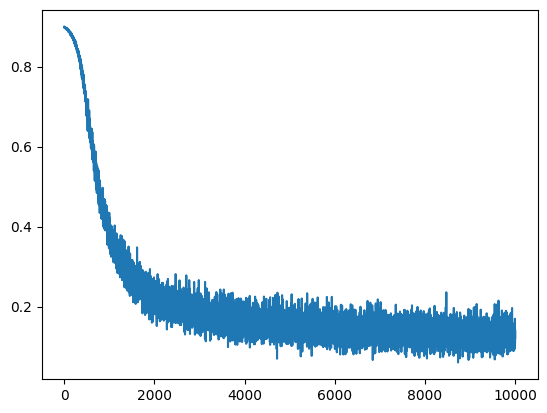

In [64]:
import matplotlib.pyplot as plt
plt.plot(cp.arange(len(loss_vector)).get(), loss_vector.get())

In [62]:
loss_vector

array([0.89838793, 0.90001187, 0.90050596, ..., 0.11551196, 0.14191989,
       0.121508  ])

In [63]:
len(loss_vector)

10000